In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# file dataset
df = pd.read_csv('Kelas C_Housing.csv')

# Menampilkan 5 baris pertama untuk verifikasi data sudah masuk
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


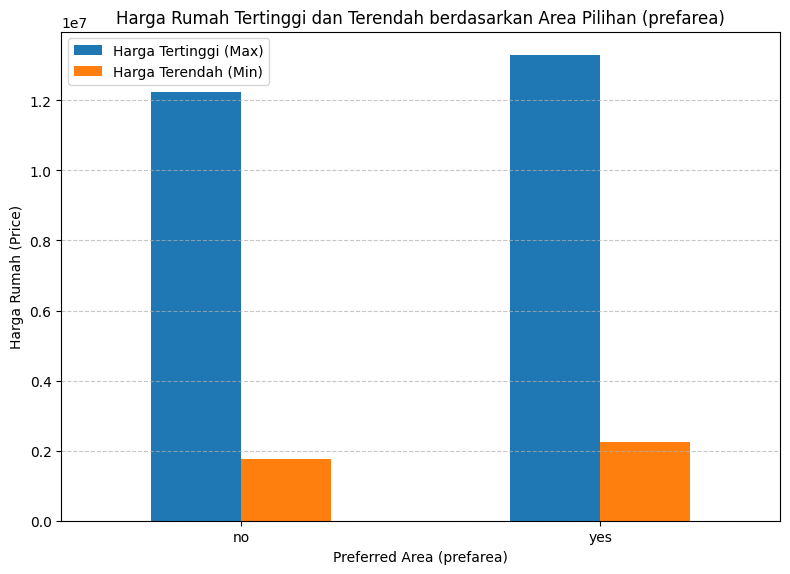

In [ ]:
# 1. Menghitung nilai maksimum dan minimum harga rumah berdasarkan prefarea
agg_prefarea = df.groupby('prefarea')['price'].agg(['max', 'min']).reset_index()

# 2. Membuat Grouped Bar Chart
# Menggunakan pandas plot untuk kemudahan membuat grouped bar chart
agg_prefarea.set_index('prefarea').plot(
    kind='bar',
    figsize=(8, 6),
    color=['#1f77b4', '#ff7f0e'] # Warna biru untuk max, oranye untuk min
)

plt.title('Harga Rumah Tertinggi dan Terendah berdasarkan Area Pilihan (prefarea)')
plt.xlabel('Preferred Area (prefarea)')
plt.ylabel('Harga Rumah (Price)')
plt.xticks(rotation=0)
plt.legend(['Harga Tertinggi (Max)', 'Harga Terendah (Min)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

/tmp/ipykernel_490/4274563467.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=count_furnishing.index, y=count_furnishing.values, palette='viridis')


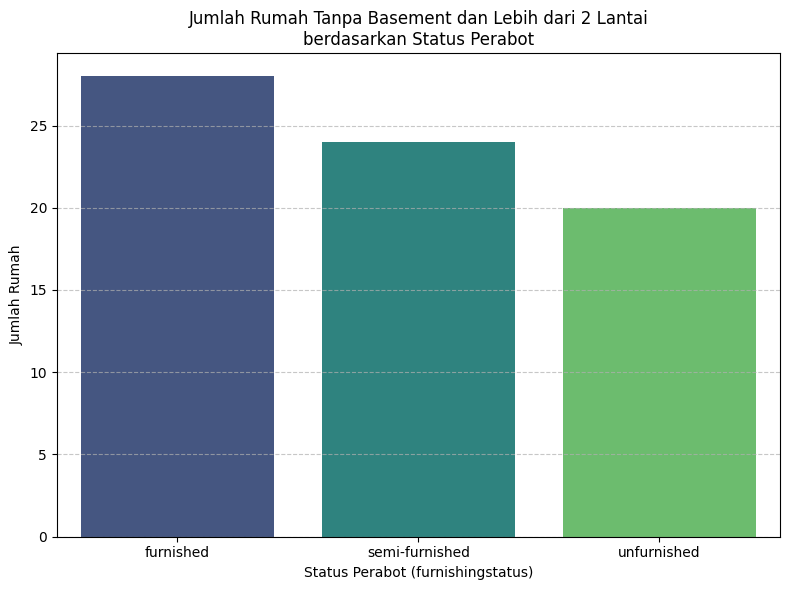

In [ ]:
# 1. Melakukan filtering data
filtered_b = df[(df['basement'] == 'no') & (df['stories'] > 2)]

# 2. Menghitung jumlah rumah berdasarkan furnishingstatus
count_furnishing = filtered_b['furnishingstatus'].value_counts()

# 3. Menampilkan ke dalam Bar Chart
plt.figure(figsize=(8, 6))
sns.barplot(x=count_furnishing.index, y=count_furnishing.values, palette='viridis')

plt.title('Jumlah Rumah Tanpa Basement dan Lebih dari 2 Lantai\nberdasarkan Status Perabot')
plt.xlabel('Status Perabot (furnishingstatus)')
plt.ylabel('Jumlah Rumah')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

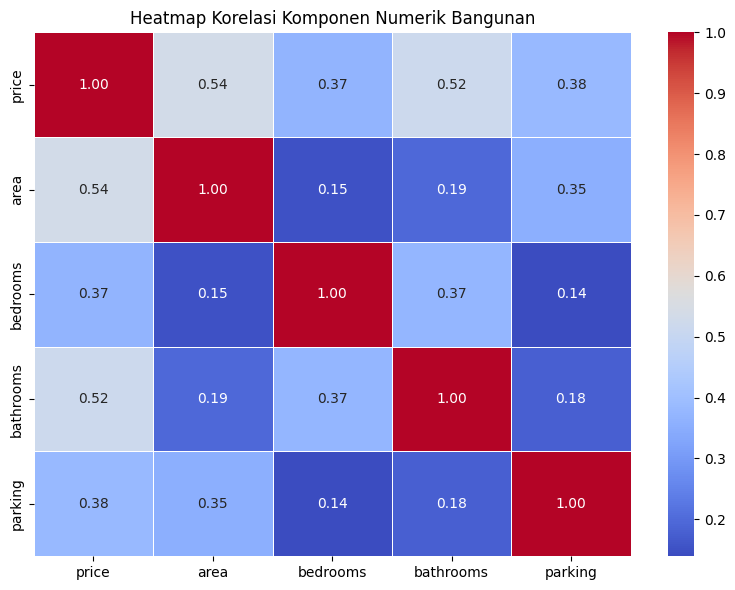

In [ ]:
# 1. Memilih kolom numerik yang diminta
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'parking']
df_numeric = df[num_cols]

# 2. Menghitung matriks korelasi (Pearson)
corr_matrix = df_numeric.corr()

# 3. Menampilkan ke dalam Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Menampilkan angka korelasi di dalam kotak
    cmap='coolwarm',     # Skema warna matriks
    fmt=".2f",           # Format 2 angka di belakang koma
    linewidths=0.5
)

plt.title('Heatmap Korelasi Komponen Numerik Bangunan')
plt.tight_layout()
plt.show()

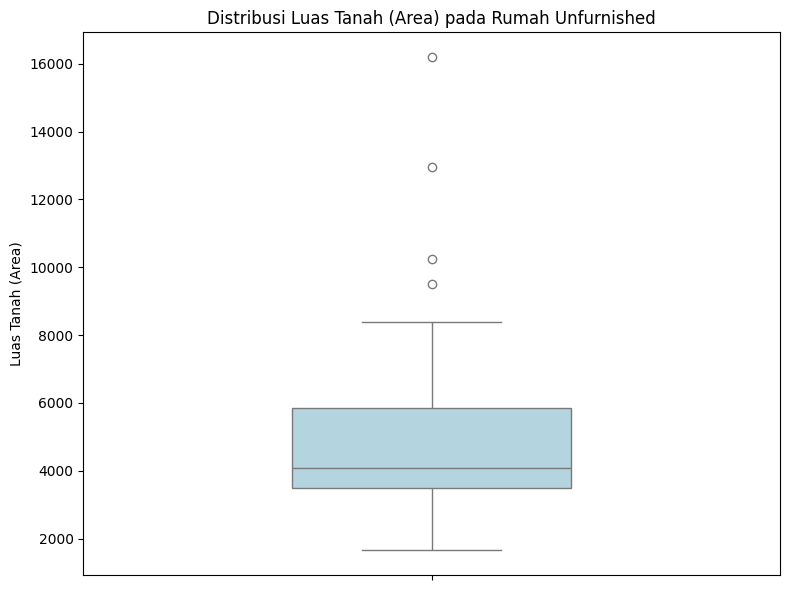

In [ ]:
# 1. Memfilter data khusus untuk rumah 'unfurnished'
df_unfurnished = df[df['furnishingstatus'] == 'unfurnished']

# 2. Menampilkan boxplot untuk mendeteksi outlier pada luas tanah
plt.figure(figsize=(8, 6))
sns.boxplot(
    y=df_unfurnished['area'],
    color='lightblue',
    width=0.4
)

plt.title('Distribusi Luas Tanah (Area) pada Rumah Unfurnished')
plt.ylabel('Luas Tanah (Area)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_490/2708426959.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_b, x='furnishingstatus', ax=axes[0, 1], palette='viridis')


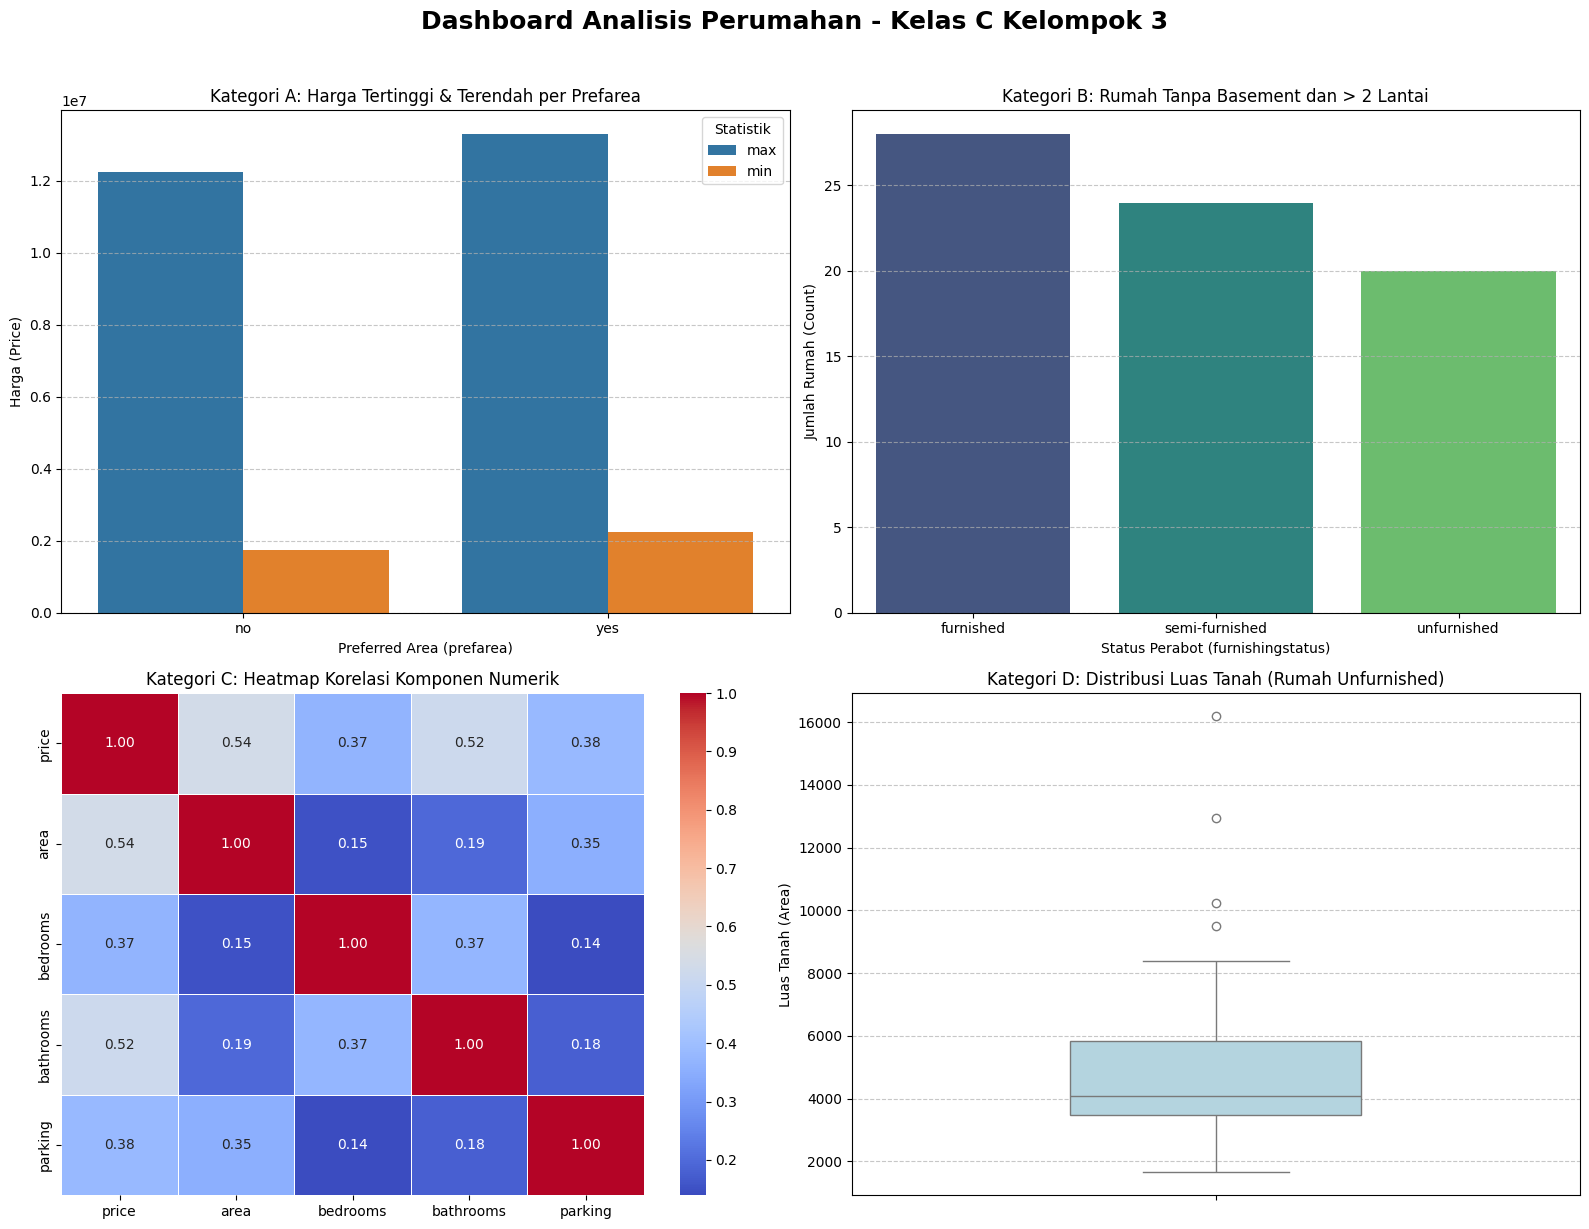

In [ ]:
# 1. IMPORT LIBRARY WAJIB
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. MEMUAT DATASET
# Menggunakan nama file verbatim sesuai ketentuan.
df = pd.read_csv('Kelas C_Housing.csv')

# 3. PERSIAPAN FIGURE DAN AXES UNTUK GRAFIK GABUNGAN (GRAFIK 5)
# Membuat grid 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Dashboard Analisis Perumahan - Kelas C Kelompok 3', fontsize=18, fontweight='bold', y=1.02)


# GRAFIK 1 (KATEGORI A) - AGREGASI

# Harga rumah tertinggi dan terendah berdasarkan prefarea dalam Grouped Bar Chart
agg_prefarea = df.groupby('prefarea')['price'].agg(['max', 'min']).reset_index()
agg_prefarea_melted = agg_prefarea.melt(id_vars='prefarea', value_vars=['max', 'min'],
                                        var_name='Statistik', value_name='Price')

sns.barplot(data=agg_prefarea_melted, x='prefarea', y='Price', hue='Statistik',
            ax=axes[0, 0], palette=['#1f77b4', '#ff7f0e'])

axes[0, 0].set_title('Kategori A: Harga Tertinggi & Terendah per Prefarea', fontsize=12)
axes[0, 0].set_xlabel('Preferred Area (prefarea)')
axes[0, 0].set_ylabel('Harga (Price)')
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.7)



# GRAFIK 2 (KATEGORI B) - TREN / FILTER

# Rumah tanpa basement (basement == 'no') & lantai (stories) > 2. Jumlah berdasarkan status perabot.
filtered_b = df[(df['basement'] == 'no') & (df['stories'] > 2)]

sns.countplot(data=filtered_b, x='furnishingstatus', ax=axes[0, 1], palette='viridis')

axes[0, 1].set_title('Kategori B: Rumah Tanpa Basement dan > 2 Lantai', fontsize=12)
axes[0, 1].set_xlabel('Status Perabot (furnishingstatus)')
axes[0, 1].set_ylabel('Jumlah Rumah (Count)')
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.7)



# GRAFIK 3 (KATEGORI C) - KORELASI

# Analisis korelasi antar komponen numerik (price, area, bedrooms, bathrooms, parking) dalam Heatmap
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'parking']
corr_matrix = df[num_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f",
            ax=axes[1, 0], linewidths=0.5)

axes[1, 0].set_title('Kategori C: Heatmap Korelasi Komponen Numerik', fontsize=12)



# GRAFIK 4 (KATEGORI D) - DISTRIBUSI

# Sebaran data luas tanah (area) untuk rumah 'unfurnished'. Deteksi outlier dengan Boxplot
df_unfurnished = df[df['furnishingstatus'] == 'unfurnished']

sns.boxplot(y=df_unfurnished['area'], ax=axes[1, 1], color='lightblue', width=0.4)

axes[1, 1].set_title('Kategori D: Distribusi Luas Tanah (Rumah Unfurnished)', fontsize=12)
axes[1, 1].set_ylabel('Luas Tanah (Area)')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.7)



# GRAFIK 5 - PENYELESAIAN TATA LETAK

# Merapikan jarak antar grafik
plt.tight_layout()

# Menampilkan hasil akhir (Grafik 5 yang berisi gabungan Grafik 1-4)
plt.show()